# State Unemployment — Vintage / Point-in-Time Data

**Goal:** Reconstruct what unemployment data was *actually available* on any given date — no look-ahead bias.  
Suitable for use as features in a predictive model.

**Key concepts:**
- **First release:** The value BLS first published for a given month (~50 days after the reference month).
- **Current (revised) value:** The latest estimate, updated via annual benchmarks.
- **Point-in-time (PIT):** At as-of date T, only use observations whose `first_release_date <= T`.

**Source:** FRED ALFRED (Archival Economic Data).  
**Vintage coverage:** ~June 2005 – present.

## 1. Setup

In [1]:
import os, time, requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

FRED_API_KEY = os.getenv("FRED_API_KEY", "12d77a40907e43a92e9a295801db18d2")
FRED_URL     = "https://api.stlouisfed.org/fred/series/observations"

STATES = [
    ("Alabama",              "AL", "01"), ("Alaska",               "AK", "02"),
    ("Arizona",              "AZ", "04"), ("Arkansas",             "AR", "05"),
    ("California",           "CA", "06"), ("Colorado",             "CO", "08"),
    ("Connecticut",          "CT", "09"), ("Delaware",             "DE", "10"),
    ("District of Columbia", "DC", "11"), ("Florida",              "FL", "12"),
    ("Georgia",              "GA", "13"), ("Hawaii",               "HI", "15"),
    ("Idaho",                "ID", "16"), ("Illinois",             "IL", "17"),
    ("Indiana",              "IN", "18"), ("Iowa",                 "IA", "19"),
    ("Kansas",               "KS", "20"), ("Kentucky",             "KY", "21"),
    ("Louisiana",            "LA", "22"), ("Maine",                "ME", "23"),
    ("Maryland",             "MD", "24"), ("Massachusetts",        "MA", "25"),
    ("Michigan",             "MI", "26"), ("Minnesota",            "MN", "27"),
    ("Mississippi",          "MS", "28"), ("Missouri",             "MO", "29"),
    ("Montana",              "MT", "30"), ("Nebraska",             "NE", "31"),
    ("Nevada",               "NV", "32"), ("New Hampshire",        "NH", "33"),
    ("New Jersey",           "NJ", "34"), ("New Mexico",           "NM", "35"),
    ("New York",             "NY", "36"), ("North Carolina",       "NC", "37"),
    ("North Dakota",         "ND", "38"), ("Ohio",                 "OH", "39"),
    ("Oklahoma",             "OK", "40"), ("Oregon",               "OR", "41"),
    ("Pennsylvania",         "PA", "42"), ("Rhode Island",         "RI", "44"),
    ("South Carolina",       "SC", "45"), ("South Dakota",         "SD", "46"),
    ("Tennessee",            "TN", "47"), ("Texas",                "TX", "48"),
    ("Utah",                 "UT", "49"), ("Vermont",              "VT", "50"),
    ("Virginia",             "VA", "51"), ("Washington",           "WA", "53"),
    ("West Virginia",        "WV", "54"), ("Wisconsin",            "WI", "55"),
    ("Wyoming",              "WY", "56"),
]
print(f"{len(STATES)} states defined")

51 states defined


## 2. Fetch vintage data (first-release per obs month)

`output_type=4` returns one row per observation month with:
- `obs_date` — the reference month
- `first_release_date` — when BLS first published this value (`realtime_start`)
- `superseded_date` — when this value was revised away (`9999-12-31` = still current)
- `value_first_release` — the initial announced value

51 API calls total.

In [2]:
def fetch_vintage(series_id, retries=4):
    for attempt in range(retries):
        data = requests.get(FRED_URL, params={
            "series_id": series_id, "api_key": FRED_API_KEY, "file_type": "json",
            "realtime_start": "1776-07-04", "realtime_end": "9999-12-31",
            "output_type": 4,
        }, timeout=60).json()
        if "error_message" in data:
            if "Too Many Requests" in data["error_message"]:
                time.sleep(2 ** (attempt + 1))
                continue
            raise ValueError(data["error_message"])
        return [o for o in data.get("observations", []) if o["value"] != "."]
    raise RuntimeError(f"Rate limit for {series_id}")


vintage_rows, failed = [], []

for i, (name, abbr, fips) in enumerate(STATES):
    sid = f"{abbr}UR"
    try:
        obs = fetch_vintage(sid)
        for o in obs:
            vintage_rows.append({
                "state": name, "abbr": abbr, "fips": fips,
                "obs_date":            pd.to_datetime(o["date"]),
                "first_release_date":  pd.to_datetime(o["realtime_start"]),
                "superseded_date":     o["realtime_end"],
                "value_first_release": float(o["value"]),
            })
        print(f"[{i+1:2d}/51] {sid}  {len(obs)} obs  first_release: {obs[0]['realtime_start']}")
    except Exception as e:
        print(f"[{i+1:2d}/51] {sid}  FAILED — {e}")
        failed.append(sid)
    time.sleep(0.3)

if failed:
    print(f"\nFailed: {failed}")

df_v = pd.DataFrame(vintage_rows)
df_v["is_current"]    = df_v["superseded_date"] == "9999-12-31"
df_v["pub_lag_days"]  = (df_v["first_release_date"] - df_v["obs_date"]).dt.days

print(f"\nVintage rows: {len(df_v):,}  |  States: {df_v['state'].nunique()}")
print(f"Obs range: {df_v['obs_date'].min().date()} - {df_v['obs_date'].max().date()}")
df_v.head()

[ 1/51] ALUR  226 obs  first_release: 2007-07-20
[ 2/51] AKUR  226 obs  first_release: 2007-07-20
[ 3/51] AZUR  226 obs  first_release: 2007-07-20
[ 4/51] ARUR  250 obs  first_release: 2005-07-22
[ 5/51] CAUR  226 obs  first_release: 2007-07-20
[ 6/51] COUR  226 obs  first_release: 2007-07-20
[ 7/51] CTUR  226 obs  first_release: 2007-07-20
[ 8/51] DEUR  226 obs  first_release: 2007-07-20
[ 9/51] DCUR  226 obs  first_release: 2007-07-20
[10/51] FLUR  226 obs  first_release: 2007-07-20
[11/51] GAUR  226 obs  first_release: 2007-07-20
[12/51] HIUR  226 obs  first_release: 2007-07-20
[13/51] IDUR  226 obs  first_release: 2007-07-20
[14/51] ILUR  250 obs  first_release: 2005-07-22
[15/51] INUR  250 obs  first_release: 2005-07-22
[16/51] IAUR  226 obs  first_release: 2007-07-20
[17/51] KSUR  226 obs  first_release: 2007-07-20
[18/51] KYUR  250 obs  first_release: 2005-07-22
[19/51] LAUR  226 obs  first_release: 2007-07-20
[20/51] MEUR  226 obs  first_release: 2007-07-20
[21/51] MDUR  226 ob

,state,abbr,fips,obs_date,first_release_date,superseded_date,value_first_release,is_current,pub_lag_days
0,Alabama,AL,01,2007-06-01,2007-07-20,2010-03-09,3.5,False,49
1,Alabama,AL,01,2007-07-01,2007-08-17,2008-03-10,3.7,False,47
2,Alabama,AL,01,2007-08-01,2007-09-25,2008-03-10,3.8,False,55
3,Alabama,AL,01,2007-09-01,2007-10-19,2008-03-10,3.7,False,48
4,Alabama,AL,01,2007-10-01,2007-11-20,2008-03-10,3.1,False,50


## 3. Fetch current (latest-revised) values

In [3]:
def fetch_current(series_id, retries=4):
    for attempt in range(retries):
        data = requests.get(FRED_URL, params={
            "series_id": series_id, "api_key": FRED_API_KEY, "file_type": "json",
            "observation_start": "1976-01-01", "frequency": "m",
        }, timeout=30).json()
        if "error_message" in data:
            if "Too Many Requests" in data["error_message"]:
                time.sleep(2 ** (attempt + 1))
                continue
            raise ValueError(data["error_message"])
        return [o for o in data.get("observations", []) if o["value"] != "."]
    raise RuntimeError(f"Rate limit for {series_id}")


current_rows = []

for i, (name, abbr, fips) in enumerate(STATES):
    sid = f"{abbr}UR"
    try:
        obs = fetch_current(sid)
        for o in obs:
            current_rows.append({
                "state": name, "abbr": abbr,
                "obs_date":      pd.to_datetime(o["date"]),
                "value_current": float(o["value"]),
            })
        print(f"[{i+1:2d}/51] {sid}  {len(obs)} obs  latest={obs[-1]['value']}%")
    except Exception as e:
        print(f"[{i+1:2d}/51] {sid}  FAILED — {e}")
    time.sleep(0.3)

df_c = pd.DataFrame(current_rows)
print(f"\nCurrent rows: {len(df_c):,}")
df_c.head()

[ 1/51] ALUR  603 obs  latest=2.8%
[ 2/51] AKUR  603 obs  latest=4.7%
[ 3/51] AZUR  603 obs  latest=4.7%
[ 4/51] ARUR  603 obs  latest=4.3%
[ 5/51] CAUR  603 obs  latest=5.3%
[ 6/51] COUR  603 obs  latest=3.9%
[ 7/51] CTUR  603 obs  latest=5.0%
[ 8/51] DEUR  603 obs  latest=5.3%
[ 9/51] DCUR  603 obs  latest=6.2%
[10/51] FLUR  603 obs  latest=4.8%
[11/51] GAUR  603 obs  latest=3.5%
[12/51] HIUR  603 obs  latest=2.5%
[13/51] IDUR  603 obs  latest=3.6%
[14/51] ILUR  603 obs  latest=5.1%
[15/51] INUR  603 obs  latest=3.2%
[16/51] IAUR  603 obs  latest=3.3%
[17/51] KSUR  603 obs  latest=3.9%
[18/51] KYUR  603 obs  latest=4.3%
[19/51] LAUR  603 obs  latest=4.4%
[20/51] MEUR  603 obs  latest=3.1%
[21/51] MDUR  603 obs  latest=4.4%
[22/51] MAUR  603 obs  latest=4.7%
[23/51] MIUR  603 obs  latest=5.0%
[24/51] MNUR  603 obs  latest=4.5%
[25/51] MSUR  603 obs  latest=3.8%
[26/51] MOUR  603 obs  latest=3.8%
[27/51] MTUR  603 obs  latest=3.5%
[28/51] NEUR  603 obs  latest=3.0%
[29/51] NVUR  603 ob

,state,abbr,obs_date,value_current
0,Alabama,AL,1976-01-01,6.7
1,Alabama,AL,1976-02-01,6.6
2,Alabama,AL,1976-03-01,6.6
3,Alabama,AL,1976-04-01,6.5
4,Alabama,AL,1976-05-01,6.4


## 4. Revision analysis

Join vintage (first release) with current to measure how much BLS revises its initial estimates.

In [4]:
df_rev = df_v.merge(df_c[["state","obs_date","value_current"]], on=["state","obs_date"], how="inner")
df_rev["revision"]     = df_rev["value_current"] - df_rev["value_first_release"]
df_rev["abs_revision"] = df_rev["revision"].abs()

print(f"Rows: {len(df_rev):,}")
print(f"\nRevision (current - first_release, pp):")
print(df_rev["revision"].describe().round(3))
print(f"\nZero revision:     {(df_rev['revision']==0).mean():.1%}")
print(f"Within +/-0.1pp:   {(df_rev['revision'].abs()<=0.1).mean():.1%}")
print(f"Within +/-0.5pp:   {(df_rev['revision'].abs()<=0.5).mean():.1%}")

cols = ["state","obs_date","first_release_date","value_first_release","value_current","revision"]
print("\nTop 10 largest upward revisions:")
top_up = df_rev.nlargest(10, "revision")[cols].copy()
top_up["obs_date"] = top_up["obs_date"].dt.strftime("%Y-%m")
top_up["first_release_date"] = top_up["first_release_date"].dt.strftime("%Y-%m-%d")
print(top_up.to_string(index=False))

Rows: 11,694

Revision (current - first_release, pp):
count    11694.000
mean        -0.048
std          0.452
min         -4.100
25%         -0.300
50%          0.000
75%          0.200
max          3.900
Name: revision, dtype: float64

Zero revision:     13.5%
Within +/-0.1pp:   24.3%
Within +/-0.5pp:   84.4%

Top 10 largest upward revisions:
        state obs_date first_release_date  value_first_release  value_current  revision
       Nevada  2020-06         2020-07-17                 15.0           18.9       3.9
     Michigan  2020-07         2020-08-21                  8.7           12.5       3.8
       Hawaii  2020-06         2020-07-17                 13.9           17.3       3.4
Massachusetts  2020-04         2020-05-22                 15.1           17.8       2.7
       Nevada  2020-07         2020-08-21                 14.0           16.7       2.7
  Connecticut  2020-05         2020-06-19                  9.4           11.9       2.5
       Hawaii  2020-07         2020-0

## 5. Publication lag

In [5]:
print("Publication lag stats (days from reference month end to first release):")
print(df_v["pub_lag_days"].describe().round(1))
print(f"\nMost common lag: {df_v['pub_lag_days'].mode().iloc[0]} days")
print(f"~{df_v['pub_lag_days'].mean()/30:.1f} months on average")

Publication lag stats (days from reference month end to first release):
count    11694.0
mean        52.3
std          8.5
min         45.0
25%         48.0
50%         50.0
75%         52.0
max        111.0
Name: pub_lag_days, dtype: float64

Most common lag: 49 days
~1.7 months on average


## 6. Point-in-time (PIT) feature panel

For each `as_of_date` on a monthly grid and each state, extract:
- The last N available monthly readings (only data with `first_release_date <= as_of_date`)
- Momentum and moving average features
- Data vintage lag (how many months behind the latest available obs is)

This is the **anti-lookahead** feature set for ML.

In [6]:
AS_OF_DATES = pd.date_range(
    start=df_v["first_release_date"].min().to_period("M").to_timestamp(),
    end=df_v["first_release_date"].max().to_period("M").to_timestamp(),
    freq="MS"
)
N_LAGS = 6

print(f"As-of dates: {len(AS_OF_DATES)}  ({AS_OF_DATES[0].date()} - {AS_OF_DATES[-1].date()})")
print(f"States: {df_v['state'].nunique()}")
print(f"Expected rows: ~{len(AS_OF_DATES) * df_v['state'].nunique():,}")

As-of dates: 251  (2005-07-01 - 2026-05-01)
States: 51
Expected rows: ~12,801


In [7]:
df_v_sorted = df_v.sort_values(["state", "obs_date"]).reset_index(drop=True)
pit_rows = []

for as_of in AS_OF_DATES:
    avail = df_v_sorted[df_v_sorted["first_release_date"] <= as_of]
    for state, grp in avail.groupby("state", sort=False):
        recent = grp.nlargest(N_LAGS, "obs_date")
        if len(recent) < N_LAGS:
            continue
        row = {
            "as_of_date":         as_of,
            "state":              state,
            "latest_obs_date":    recent["obs_date"].iloc[0],
            "vintage_lag_months": int(
                (as_of.to_period("M") - recent["obs_date"].iloc[0].to_period("M")).n
            ),
        }
        vals = recent["value_first_release"].values
        for k in range(N_LAGS):
            row[f"urate_t{k}"] = vals[k]  # t0=latest available, t1=one prior, ...
        pit_rows.append(row)

pit = pd.DataFrame(pit_rows)

# Derived features
pit["urate_mom1"]  = pit["urate_t0"] - pit["urate_t1"]   # 1-month change
pit["urate_mom3"]  = pit["urate_t0"] - pit["urate_t3"]   # 3-month change
pit["urate_mean3"] = pit[["urate_t0","urate_t1","urate_t2"]].mean(axis=1)
pit["urate_mean6"] = pit[[f"urate_t{k}" for k in range(6)]].mean(axis=1)

print(f"PIT rows: {len(pit):,}")
print(f"Columns: {list(pit.columns)}")
pit.head(8)

PIT rows: 11,439
Columns: ['as_of_date', 'state', 'latest_obs_date', 'vintage_lag_months', 'urate_t0', 'urate_t1', 'urate_t2', 'urate_t3', 'urate_t4', 'urate_t5', 'urate_mom1', 'urate_mom3', 'urate_mean3', 'urate_mean6']


,as_of_date,state,latest_obs_date,vintage_lag_months,urate_t0,urate_t1,urate_t2,urate_t3,urate_t4,urate_t5,urate_mom1,urate_mom3,urate_mean3,urate_mean6
0,2006-01-01,Arkansas,2005-11-01,2,4.8,4.9,5.7,5.1,4.9,4.8,-0.1,-0.3,5.133333,5.033333
1,2006-01-01,Illinois,2005-11-01,2,5.3,5.5,5.7,5.8,6.0,6.0,-0.2,-0.5,5.500000,5.716667
2,2006-01-01,Indiana,2005-11-01,2,5.3,5.4,5.3,5.4,5.4,5.1,-0.1,-0.1,5.333333,5.316667
3,2006-01-01,Kentucky,2005-11-01,2,6.2,6.0,5.7,5.4,5.9,5.7,0.2,0.8,5.966667,5.816667
4,2006-01-01,Mississippi,2005-11-01,2,9.5,9.6,9.6,6.8,6.5,7.0,-0.1,2.7,9.566667,8.166667
5,2006-01-01,Missouri,2005-11-01,2,5.6,5.0,4.8,4.6,5.6,5.4,0.6,1.0,5.133333,5.166667
6,2006-01-01,Tennessee,2005-11-01,2,5.8,5.6,5.1,5.3,5.5,6.0,0.2,0.5,5.500000,5.550000
7,2006-02-01,Arkansas,2005-12-01,2,4.5,4.8,4.9,5.7,5.1,4.9,-0.3,-1.2,4.733333,4.983333


In [8]:
# Sanity check: at 2020-03-01 we should see data only through ~Jan 2020
# (pub lag ~50 days means Jan data released around March 20)
check = pit[pit["as_of_date"] == pd.Timestamp("2020-03-01")].head(6)
print("PIT snapshot as of 2020-03-01:")
print(check[["state","latest_obs_date","vintage_lag_months","urate_t0","urate_t1","urate_mom1"]].to_string(index=False))

PIT snapshot as of 2020-03-01:
     state latest_obs_date  vintage_lag_months  urate_t0  urate_t1  urate_mom1
   Alabama      2019-12-01                   3       2.7       2.7         0.0
    Alaska      2019-12-01                   3       6.1       6.1         0.0
   Arizona      2019-12-01                   3       4.6       4.7        -0.1
  Arkansas      2019-12-01                   3       3.6       3.6         0.0
California      2019-12-01                   3       3.9       3.9         0.0
  Colorado      2019-12-01                   3       2.5       2.6        -0.1


## 7. Save outputs

In [9]:
df_v.drop(columns="superseded_date").to_csv("vintage_first_release.csv", index=False)

df_rev[["state","abbr","fips","obs_date","first_release_date",
        "value_first_release","value_current","revision","pub_lag_days","is_current"
       ]].to_csv("vintage_revisions.csv", index=False)

pit.to_csv("pit_features.csv", index=False)

print("Saved:")
print("  vintage_first_release.csv  — raw first-release values per obs month")
print("  vintage_revisions.csv      — first release vs current + revision magnitude")
print("  pit_features.csv           — point-in-time ML feature panel (no look-ahead)")

Saved:
  vintage_first_release.csv  — raw first-release values per obs month
  vintage_revisions.csv      — first release vs current + revision magnitude
  pit_features.csv           — point-in-time ML feature panel (no look-ahead)


## 8. Visualizations

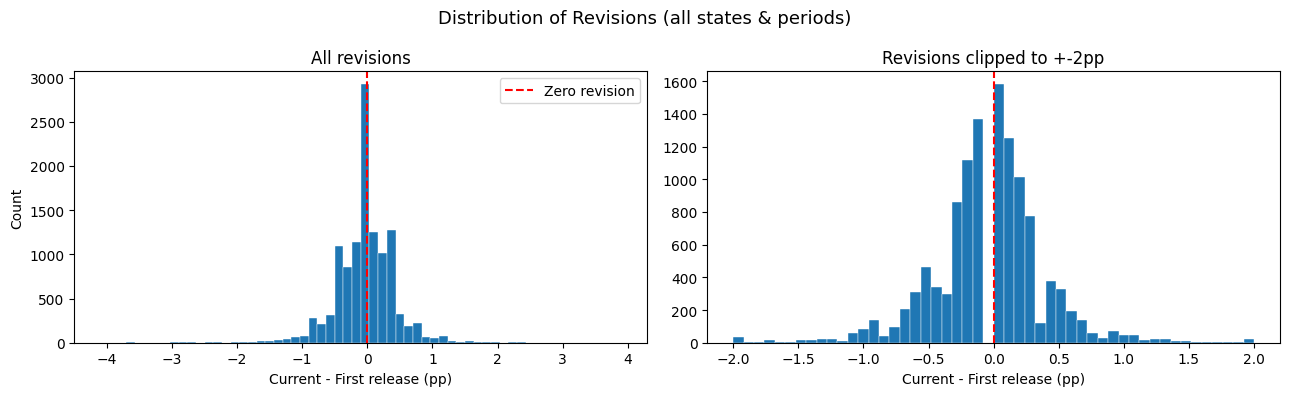

In [10]:
# ── Plot 1: Revision distribution ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_rev["revision"], bins=60, edgecolor="white", linewidth=0.3)
axes[0].axvline(0, color="red", lw=1.5, ls="--", label="Zero revision")
axes[0].set(title="All revisions", xlabel="Current - First release (pp)", ylabel="Count")
axes[0].legend()

axes[1].hist(df_rev["revision"].clip(-2, 2), bins=50, edgecolor="white", linewidth=0.3)
axes[1].axvline(0, color="red", lw=1.5, ls="--")
axes[1].set(title="Revisions clipped to +-2pp", xlabel="Current - First release (pp)")

fig.suptitle("Distribution of Revisions (all states & periods)", fontsize=13)
plt.tight_layout()
plt.show()

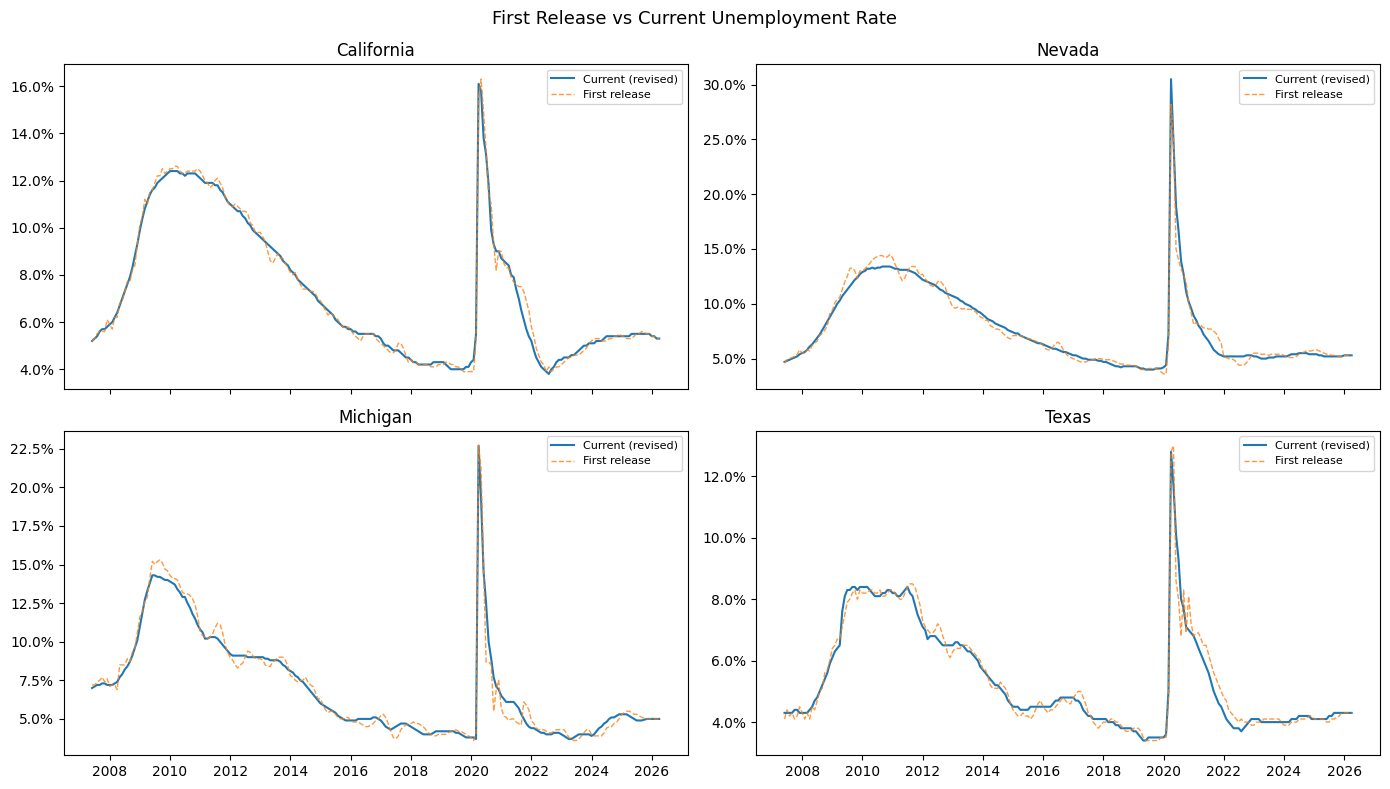

In [11]:
# ── Plot 2: First release vs current — selected states ───────────────────────
HIGHLIGHT = ["California", "Nevada", "Michigan", "Texas"]
fmt = mticker.FormatStrFormatter("%.1f%%")
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, state in zip(axes.flat, HIGHLIGHT):
    sub = df_rev[df_rev["state"] == state].sort_values("obs_date")
    ax.plot(sub["obs_date"], sub["value_current"],       lw=1.5, label="Current (revised)")
    ax.plot(sub["obs_date"], sub["value_first_release"], lw=1, ls="--", alpha=0.8, label="First release")
    ax.set_title(state)
    ax.yaxis.set_major_formatter(fmt)
    ax.legend(fontsize=8)

fig.suptitle("First Release vs Current Unemployment Rate", fontsize=13)
plt.tight_layout()
plt.show()

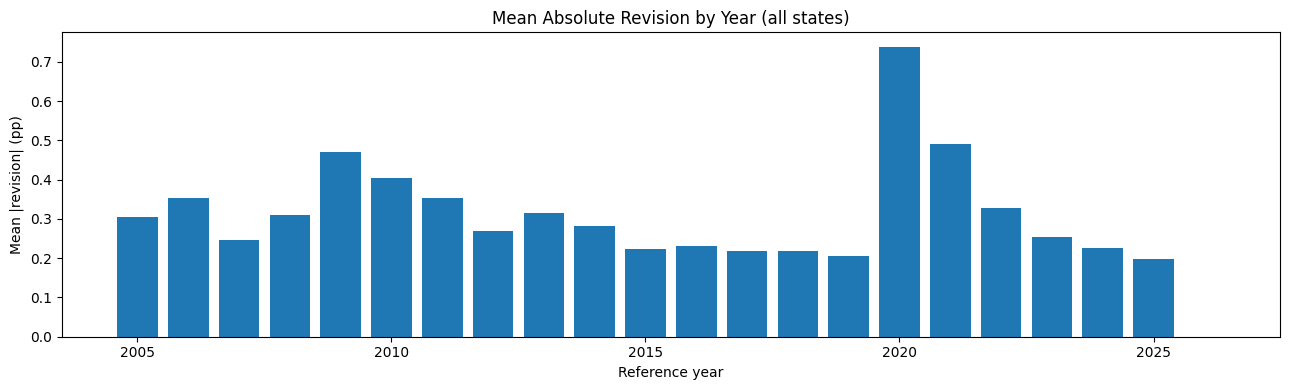

In [12]:
# ── Plot 3: Mean absolute revision by year ───────────────────────────────────
df_rev["year"] = df_rev["obs_date"].dt.year
rev_by_year = df_rev.groupby("year")["abs_revision"].mean()

fig, ax = plt.subplots(figsize=(13, 4))
ax.bar(rev_by_year.index, rev_by_year.values)
ax.set(title="Mean Absolute Revision by Year (all states)",
       xlabel="Reference year", ylabel="Mean |revision| (pp)")
plt.tight_layout()
plt.show()

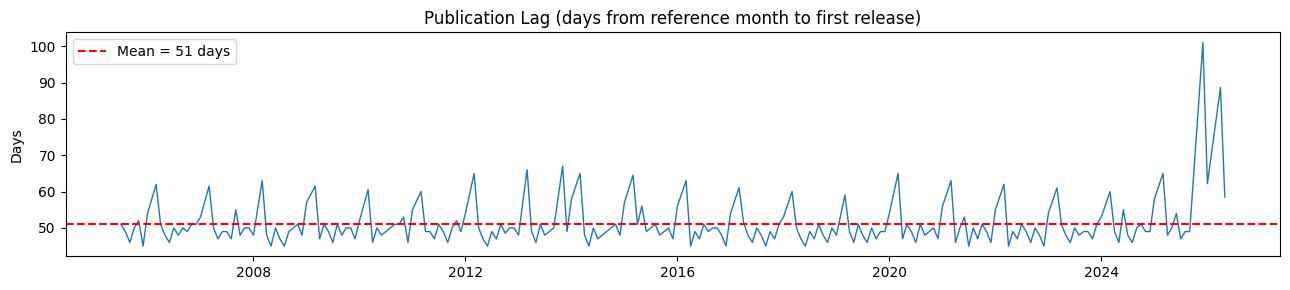

In [13]:
# ── Plot 4: Publication lag over time ─────────────────────────────────────────
lag_by_month = df_v.groupby(df_v["first_release_date"].dt.to_period("M"))["pub_lag_days"].mean()
lag_by_month.index = lag_by_month.index.to_timestamp()

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(lag_by_month.index, lag_by_month.values, lw=1)
ax.axhline(lag_by_month.mean(), color="red", ls="--", lw=1.5,
           label=f"Mean = {lag_by_month.mean():.0f} days")
ax.set(title="Publication Lag (days from reference month to first release)", ylabel="Days")
ax.legend()
plt.tight_layout()
plt.show()

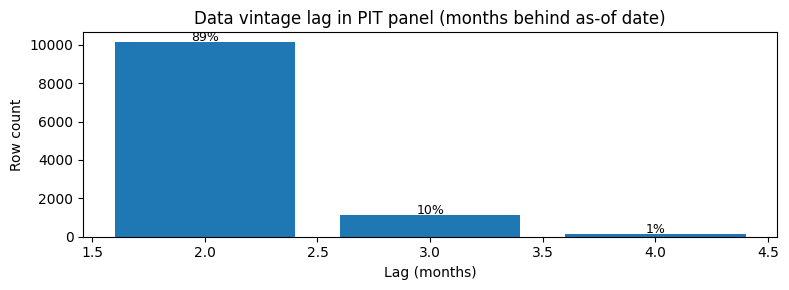

In [14]:
# ── Plot 5: Data vintage lag in PIT panel ─────────────────────────────────────
lag_dist = pit["vintage_lag_months"].value_counts().sort_index()
pct = lag_dist / lag_dist.sum()

fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(lag_dist.index, lag_dist.values)
for k, v in pct.items():
    ax.text(k, lag_dist[k] + 50, f"{v:.0%}", ha="center", fontsize=9)
ax.set(title="Data vintage lag in PIT panel (months behind as-of date)",
       xlabel="Lag (months)", ylabel="Row count")
plt.tight_layout()
plt.show()

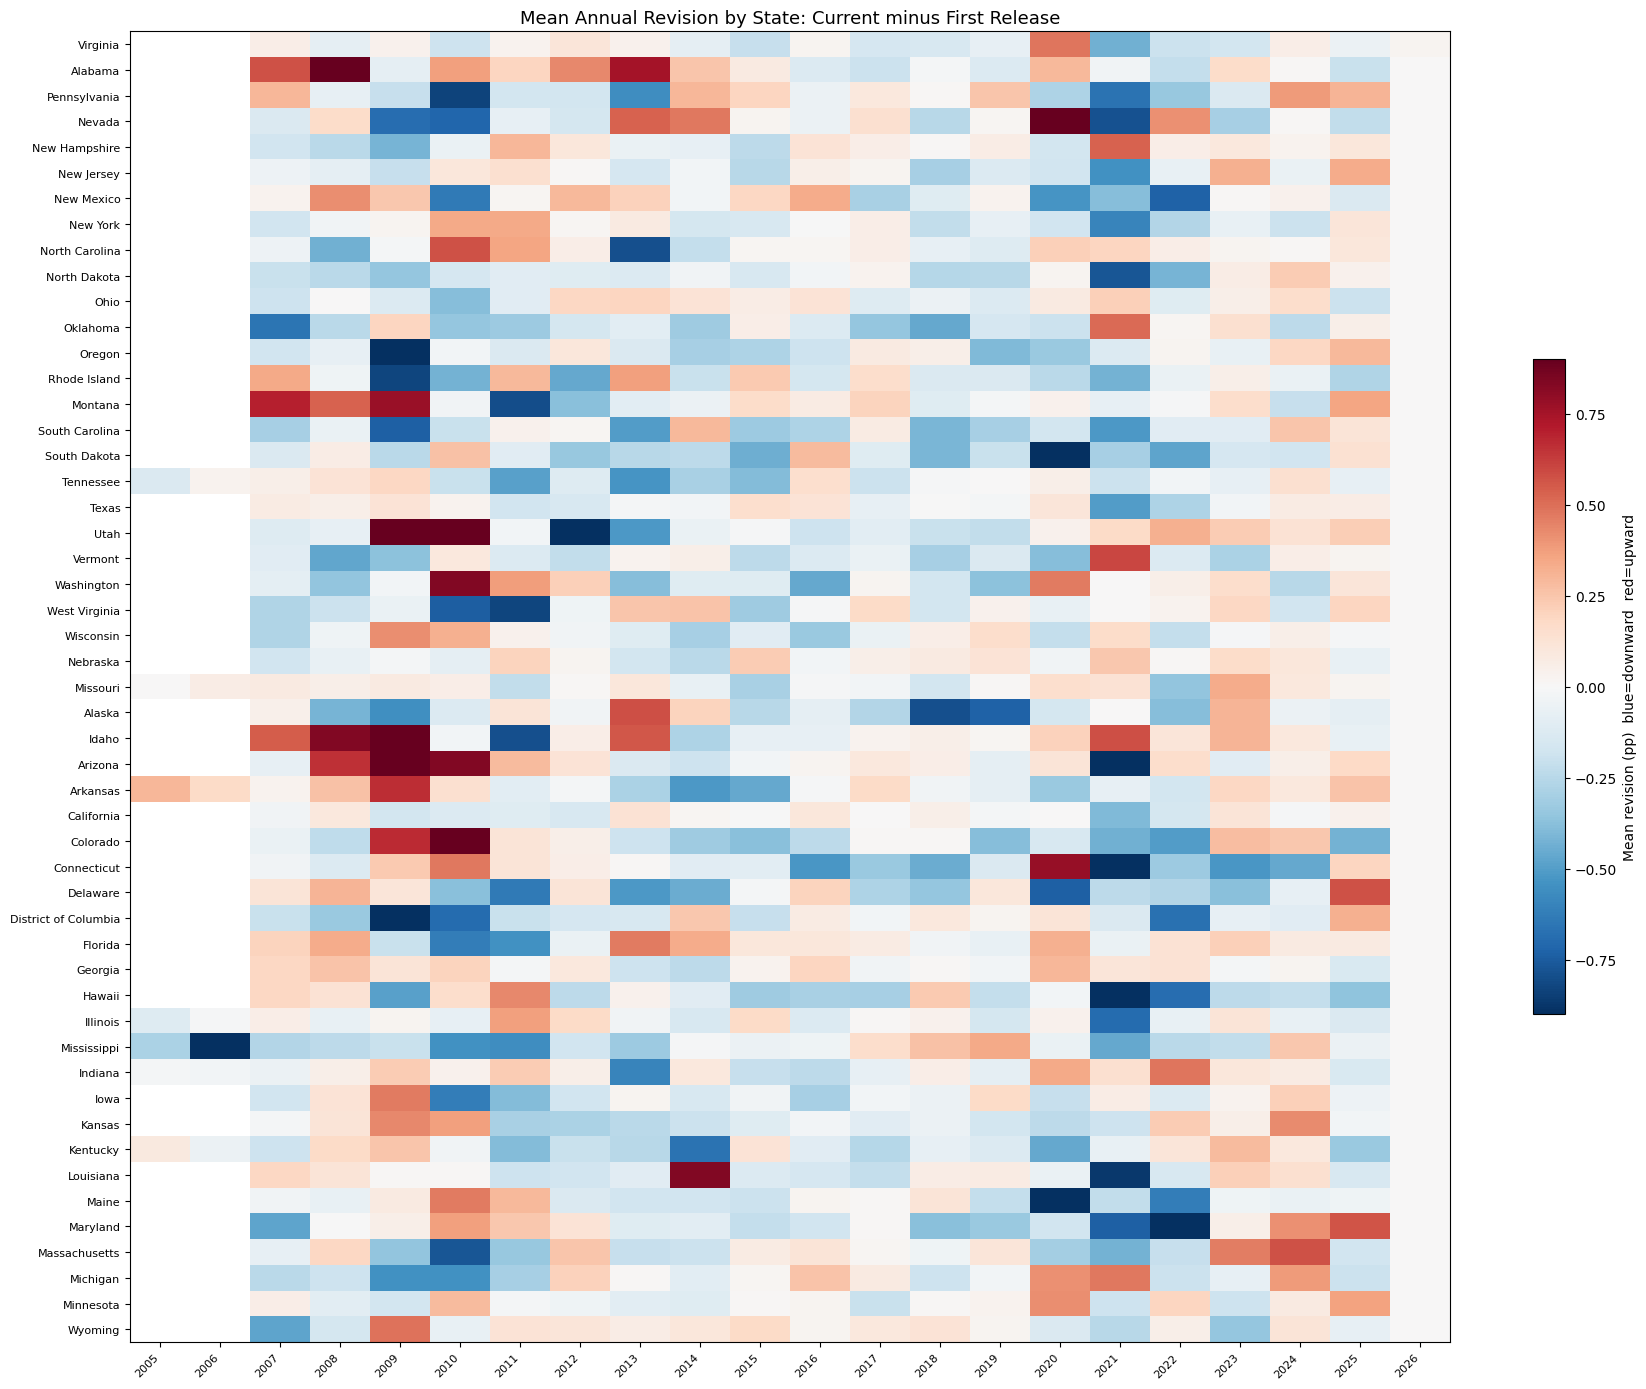

In [15]:
# ── Plot 6: Revision heatmap — state x year ───────────────────────────────────
heat = df_rev.groupby(["state","year"])["revision"].mean().unstack("year")
heat = heat.sort_values(heat.columns[-1], ascending=False)
vmax = df_rev["revision"].abs().quantile(0.95)

fig, ax = plt.subplots(figsize=(18, 14))
im = ax.imshow(heat.values, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index, fontsize=8)
plt.colorbar(im, ax=ax, label="Mean revision (pp)  blue=downward  red=upward", shrink=0.5)
ax.set_title("Mean Annual Revision by State: Current minus First Release", fontsize=13)
plt.tight_layout()
plt.show()

## 9. Build a model-ready feature matrix

Join PIT features (inputs) with future unemployment (target) at a chosen horizon.

In [16]:
TARGET_HORIZON = 3  # predict 3 months ahead of as_of_date

# Target: current (final revised) value at as_of_date + horizon
df_target = df_c[["state","obs_date","value_current"]].copy()
df_target["as_of_date"] = df_target["obs_date"] - pd.DateOffset(months=TARGET_HORIZON)
df_target = df_target.rename(columns={"value_current": f"target_urate_t{TARGET_HORIZON}m"})

model_df = (
    pit
    .merge(
        df_target[["as_of_date","state",f"target_urate_t{TARGET_HORIZON}m"]],
        on=["as_of_date","state"],
        how="inner",
    )
    .dropna()
)

feature_cols = [c for c in model_df.columns
                if c not in ["as_of_date","state","latest_obs_date",f"target_urate_t{TARGET_HORIZON}m"]]

print(f"Model-ready rows: {len(model_df):,}")
print(f"Features ({len(feature_cols)}): {feature_cols}")
print(f"Target: target_urate_t{TARGET_HORIZON}m")

model_df.to_csv("model_features.csv", index=False)
print("\nSaved model_features.csv")
model_df.head(8)

Model-ready rows: 11,184
Features (11): ['vintage_lag_months', 'urate_t0', 'urate_t1', 'urate_t2', 'urate_t3', 'urate_t4', 'urate_t5', 'urate_mom1', 'urate_mom3', 'urate_mean3', 'urate_mean6']
Target: target_urate_t3m

Saved model_features.csv


,as_of_date,state,latest_obs_date,vintage_lag_months,urate_t0,urate_t1,urate_t2,urate_t3,urate_t4,urate_t5,urate_mom1,urate_mom3,urate_mean3,urate_mean6,target_urate_t3m
0,2006-01-01,Arkansas,2005-11-01,2,4.8,4.9,5.7,5.1,4.9,4.8,-0.1,-0.3,5.133333,5.033333,5.2
1,2006-01-01,Illinois,2005-11-01,2,5.3,5.5,5.7,5.8,6.0,6.0,-0.2,-0.5,5.500000,5.716667,4.7
2,2006-01-01,Indiana,2005-11-01,2,5.3,5.4,5.3,5.4,5.4,5.1,-0.1,-0.1,5.333333,5.316667,5.0
3,2006-01-01,Kentucky,2005-11-01,2,6.2,6.0,5.7,5.4,5.9,5.7,0.2,0.8,5.966667,5.816667,5.8
4,2006-01-01,Mississippi,2005-11-01,2,9.5,9.6,9.6,6.8,6.5,7.0,-0.1,2.7,9.566667,8.166667,6.3
5,2006-01-01,Missouri,2005-11-01,2,5.6,5.0,4.8,4.6,5.6,5.4,0.6,1.0,5.133333,5.166667,4.8
6,2006-01-01,Tennessee,2005-11-01,2,5.8,5.6,5.1,5.3,5.5,6.0,0.2,0.5,5.500000,5.550000,5.4
7,2006-02-01,Arkansas,2005-12-01,2,4.5,4.8,4.9,5.7,5.1,4.9,-0.3,-1.2,4.733333,4.983333,5.2
